# Long-range dependence: reaction-coordinate scan -- LOREM EQMP smoketest

Same worked examples as `02_long_range_scan.ipynb`, built on `long_range_tests.py`, applied to the **LOREM EQMP smoketest** model (`../data/lorem-eqmp-smoketest/model.pt`, family: LOREM). We take the SN2 system (CH₃F + I⁻, atoms `C H H H F I`) and pull the leaving iodide away from the CH₃F fragment along the reaction coordinate, scanning out to large distances (tens of Å) to see this model's finite interaction range / cutoff show up directly in the energy and forces.

> Not part of the sn2-matched-* series -- a separate smoketest run of an equivariant message-passing LOREM variant (see diag.yaml in this directory), included here as 'the other model' with a usable model.pt.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import to_hex

from ase.io import read
from ase.visualize.plot import plot_atoms
from ase.data.colors import jmol_colors

import sphericart.torch  # pre-import BEFORE loading the model
from metatomic_ase import MetatomicCalculator

from long_range_tests import (
    displace_atom_test,
    fragment_separation_test,
    estimate_cutoff,
)

# a bit of shared plot styling -- thin lines, recessive grid, no boxed-in axes
plt.rcParams.update({
    "figure.dpi": 120,
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linewidth": 0.6,
    "legend.frameon": False,
})

# colorblind-safe categorical palette (Okabe-Ito), one fixed color per atom index
ATOM_COLORS = ["#0072B2", "#56B4E9", "#009E73", "#E69F00", "#D55E00", "#CC79A7"]
HIGHLIGHT = "#D55E00"  # used to call out the leaving group / the empirical cutoff


mkdir -p failed for path /home/boittier/.config/matplotlib: [Errno 13] Permission denied: '/home/boittier/.config/matplotlib'
Matplotlib created a temporary cache directory at /tmp/matplotlib-kiwvgagg because there was an issue with the default path ({configdir}); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.
/home/boittier/metawork/.venv/lib/python3.12/site-packages/vesin/metatomic/__init__.py:26: UserWarning: Found metatomic.torch v0.2.0.dev1125+git.fe7ef0a, but vesin.metatomic was only tested with metatomic.torch >=0.1.3,<0.2. This may lead to unexpected errors. Please install a compatible version of metatomic.torch if you encounter any issues.
  warnings.warn(


## Setup

As in `02_long_range_scan.ipynb`, we use the shared reference structure `data/sn2/sn2.xyz` (frame 0) for every model in this series, so the reaction-coordinate geometry is identical across notebooks and the results are directly comparable. F has bonded to carbon (`C-F` ≈ 1.4 Å) and I has already left to ≈ 7.4 Å in that snapshot; we re-anchor I onto the C···I axis and scan its distance directly, from a compressed/bonded-ish separation out to 32 Å.

In [2]:
calc = MetatomicCalculator(
    "../data/lorem-eqmp-smoketest/model.pt",
)

atoms0 = read("../data/sn2/sn2.xyz", index=0)
symbols = atoms0.get_chemical_symbols()
labels = [f"{i} {s}" for i, s in enumerate(symbols)]
C, I = 0, 5  # atom indices: carbon, leaving iodide

d = atoms0.get_all_distances()
print(f"original snapshot -- C-F: {d[C, 4]:.2f} Å   C-I: {d[C, I]:.2f} Å")

# unit vector along the current C -> I axis (the reaction coordinate direction)
direction = atoms0.positions[I] - atoms0.positions[C]
direction = direction / np.linalg.norm(direction)

# re-anchor I onto that axis at C's own position, so `distances` below are
# absolute C...I separations rather than offsets from an arbitrary snapshot
atoms0.positions[I] = atoms0.positions[C].copy()

distances = np.linspace(1.5, 32.0, 62)  # Å, absolute C...I distance


original snapshot -- C-F: 1.39 Å   C-I: 7.44 Å


## 1. Reaction-coordinate scan (`displace_atom_test`)

Move I along the reaction coordinate through `distances` and record the energy and the forces on the CH₃F fragment (atoms 0-4) at each point.

In [3]:
result = displace_atom_test(
    atoms0, calc, probe_index=I, distances=distances,
    direction=direction, reference_indices=[0, 1, 2, 3, 4],
)

# how far each force still differs from its fully-separated (d=32 Å) value --
# isolates the *I-dependent* part of the force, since the fragment's own
# non-equilibrium internal forces don't vanish with distance and would
# otherwise swamp the signal
delta_forces = result["forces"] - result["forces"][-1]
delta_force_mag = np.linalg.norm(delta_forces, axis=-1)  # (n_dist, n_ref_atoms)
max_delta = delta_force_mag.max(axis=-1)

cutoff_distance = estimate_cutoff(result["distance"], max_delta, threshold=0.01)
print(f"empirical cutoff: {cutoff_distance:.1f} Å" if cutoff_distance is not None
      else "empirical cutoff: never dropped below threshold within 32 Å")


empirical cutoff: 23.5 Å


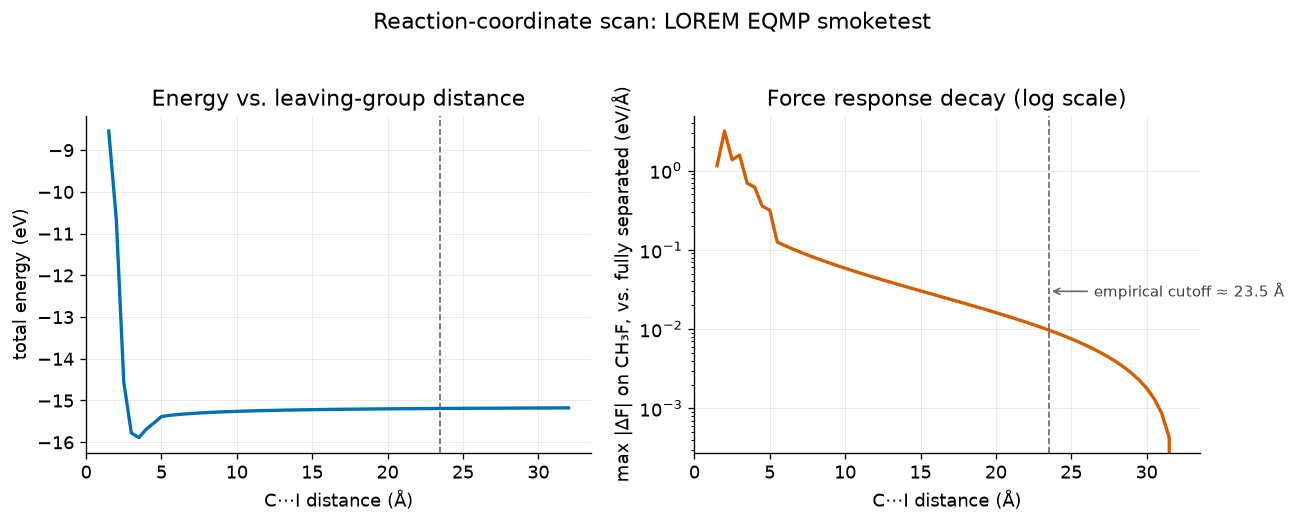

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

ax = axes[0]
ax.plot(result["distance"], result["energy"], color=ATOM_COLORS[0], linewidth=2)
if cutoff_distance is not None:
    ax.axvline(cutoff_distance, color="0.4", linestyle="--", linewidth=1)
ax.set_xlabel("C···I distance (Å)")
ax.set_ylabel("total energy (eV)")
ax.set_title("Energy vs. leaving-group distance")

ax = axes[1]
ax.semilogy(result["distance"], max_delta, color=HIGHLIGHT, linewidth=2)
if cutoff_distance is not None:
    ax.axvline(cutoff_distance, color="0.4", linestyle="--", linewidth=1)
    ax.annotate(f"empirical cutoff ≈ {cutoff_distance:.1f} Å",
                xy=(cutoff_distance, 3e-2), xytext=(cutoff_distance + 3, 3e-2),
                fontsize=9, color="0.25", va="center",
                arrowprops=dict(arrowstyle="->", color="0.4", lw=1))
ax.set_xlabel("C···I distance (Å)")
ax.set_ylabel("max |ΔF| on CH₃F, vs. fully separated (eV/Å)")
ax.set_title("Force response decay (log scale)")

fig.suptitle("Reaction-coordinate scan: LOREM EQMP smoketest", y=1.03)
fig.tight_layout()


### Per-atom force magnitude and components

Same scan, broken down per atom and per Cartesian component. Colors are fixed per atom index throughout this series (Okabe-Ito, colorblind-safe).

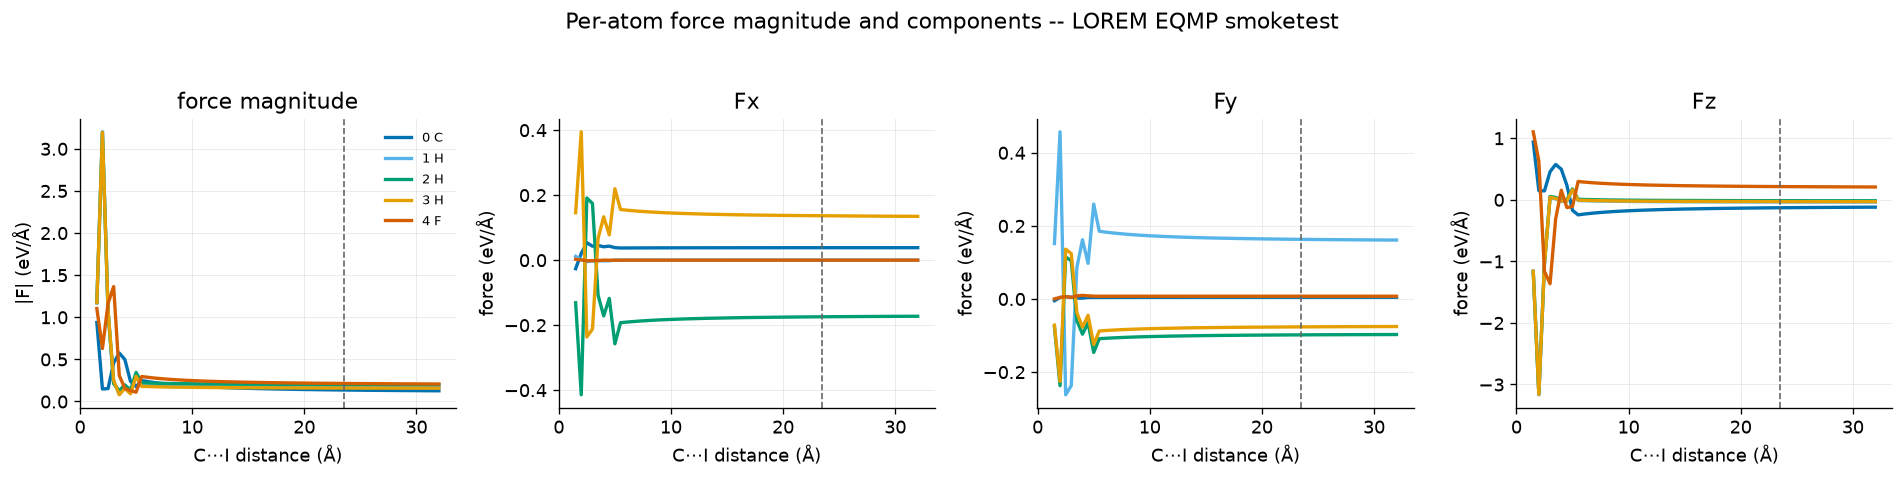

In [5]:
per_atom_mag = np.linalg.norm(result["forces"], axis=-1)  # (n_dist, n_ref_atoms)
ref_labels = [labels[j] for j in [0, 1, 2, 3, 4]]

fig, axes = plt.subplots(1, 4, figsize=(16, 3.8), sharex=True)

ax = axes[0]
for j, lab in enumerate(ref_labels):
    ax.plot(result["distance"], per_atom_mag[:, j], color=ATOM_COLORS[j],
            linewidth=2, label=lab)
if cutoff_distance is not None:
    ax.axvline(cutoff_distance, color="0.4", linestyle="--", linewidth=1)
ax.set_ylabel("|F| (eV/Å)")
ax.set_title("force magnitude")
ax.set_xlabel("C···I distance (Å)")
ax.legend(fontsize=8, loc="upper right")

comp_names = ["Fx", "Fy", "Fz"]
for k, comp in enumerate(comp_names):
    ax = axes[k + 1]
    for j, lab in enumerate(ref_labels):
        ax.plot(result["distance"], result["forces"][:, j, k], color=ATOM_COLORS[j],
                linewidth=2, label=lab)
    if cutoff_distance is not None:
        ax.axvline(cutoff_distance, color="0.4", linestyle="--", linewidth=1)
    ax.set_title(comp)
    ax.set_xlabel("C···I distance (Å)")
    ax.set_ylabel("force (eV/Å)")

fig.suptitle("Per-atom force magnitude and components -- LOREM EQMP smoketest", y=1.04)
fig.tight_layout()


### Structure snapshots along the scan

`ase.visualize.plot.plot_atoms` snapshots at a few distances, using standard Jmol element colors (grey C, white H, green F) so the geometry is recognizable at a glance -- with I⁻ (the atom actually being moved) highlighted in the same orange used for the cutoff annotations above, and the panel nearest the empirical cutoff outlined.

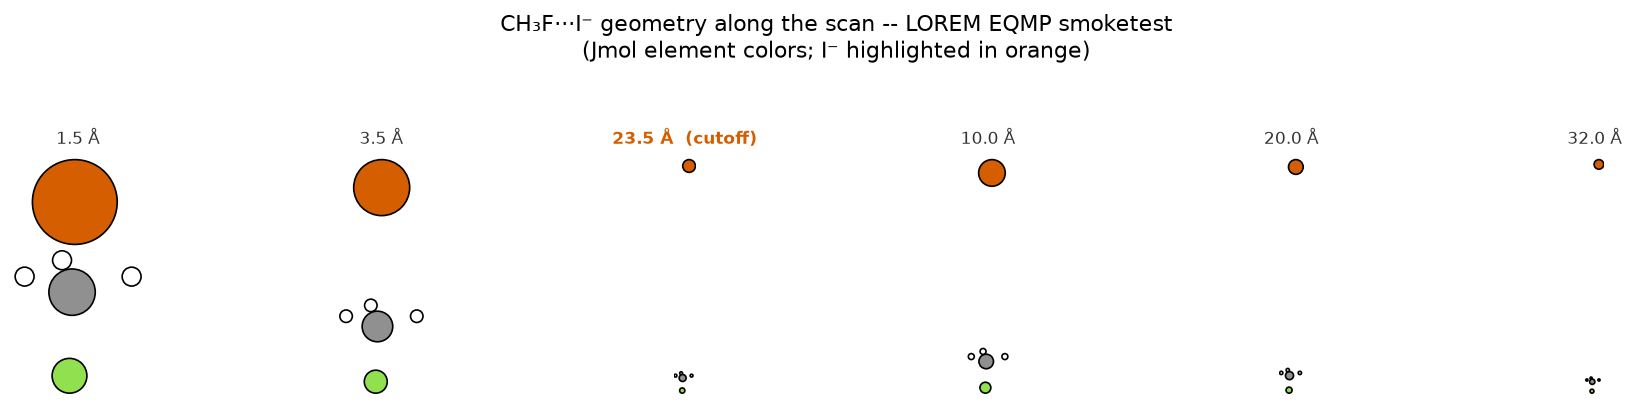

In [6]:
snapshot_distances = [1.5, 3.5, cutoff_distance if cutoff_distance is not None else 6.0, 10.0, 20.0, 32.0]
z = atoms0.get_atomic_numbers()
base_colors = [to_hex(jmol_colors[zi]) for zi in z]

fig, axes = plt.subplots(1, len(snapshot_distances), figsize=(16, 3.2))

for ax, dist in zip(axes, snapshot_distances):
    snap = atoms0.copy()
    snap.positions[I] = atoms0.positions[C] + direction * dist
    colors = list(base_colors)
    colors[I] = HIGHLIGHT
    plot_atoms(snap, ax, radii=0.5, colors=colors, rotation="-80x,10y,0z")
    is_cutoff = np.isclose(dist, snapshot_distances[2])
    ax.set_title(f"{dist:.1f} Å" + ("  (cutoff)" if is_cutoff else ""),
                 fontsize=10, color=HIGHLIGHT if is_cutoff else "0.2",
                 fontweight="bold" if is_cutoff else "normal")
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor(HIGHLIGHT if is_cutoff else "0.85")
        spine.set_linewidth(2 if is_cutoff else 1)

fig.suptitle(
    "CH₃F···I⁻ geometry along the scan -- LOREM EQMP smoketest\n"
    "(Jmol element colors; I⁻ highlighted in orange)",
    y=1.06,
)
fig.tight_layout()


## 2. Size-consistency corroboration (`fragment_separation_test`)

Same displacement, viewed as a fragmentation: CH₃F (atoms 0-4) vs. I⁻ (atom 5) alone. The interaction energy should spike at short, unphysically compressed separations (steric repulsion) and decay to ~0 past the same cutoff found above (or the model's genuine long-range tail, if it has one).

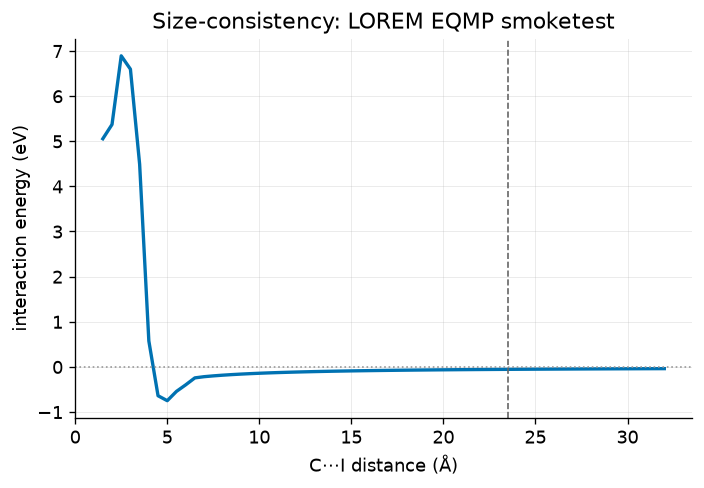

In [7]:
fragmentation = fragment_separation_test(
    atoms0, calc, [0, 1, 2, 3, 4], [I],
    separations=distances - distances[0], axis=direction,
)

fig, ax = plt.subplots(figsize=(6, 4.2))
ax.plot(result["distance"], fragmentation["interaction_energy"],
        color=ATOM_COLORS[0], linewidth=2)
ax.axhline(0, color="0.6", linewidth=1, linestyle=":")
if cutoff_distance is not None:
    ax.axvline(cutoff_distance, color="0.4", linestyle="--", linewidth=1)
ax.set_xlabel("C···I distance (Å)")
ax.set_ylabel("interaction energy (eV)")
ax.set_title("Size-consistency: LOREM EQMP smoketest")
fig.tight_layout()


## Takeaways

- Empirical cutoff for **LOREM EQMP smoketest**: **23.5 Å**. LOREM is designed to carry a genuine long-range electrostatic term, and that shows up directly here: the empirical cutoff is much larger than the BPNN/PET models in this series, consistent with a real (not just numerically slow-decaying) long-range interaction.
- Past that point, the per-atom force curves flatten to a non-zero plateau of ≈0.207 eV/Å: that's the CH₃F fragment's own intrinsic force in this non-equilibrium geometry, not residual coupling to I⁻.
- Total energy changes by ≈6.63 eV from the most compressed to the most separated geometry sampled here.
- The interaction-energy view (`fragment_separation_test`) corroborates the same picture independently: a short-range repulsive spike at compressed separations, decaying at large separation.